In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

# Load dataset
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
from sklearn.model_selection import train_test_split

# First split: Train (70%) and Temp (30%)
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Second split: Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (14448, 8)
Validation size: (3096, 8)
Test size: (3096, 8)


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation & test
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

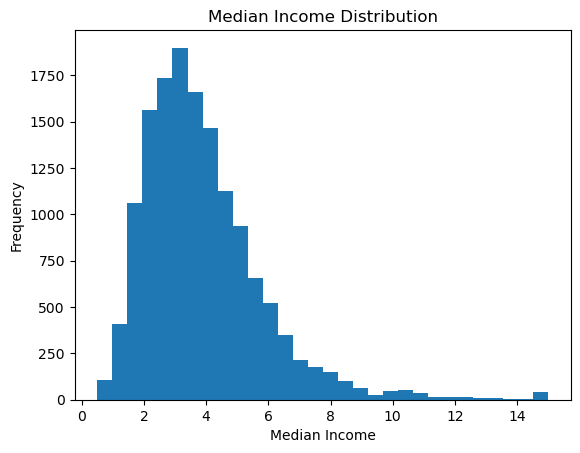

In [4]:
plt.hist(X_train['MedInc'], bins=30)
plt.title("Median Income Distribution")
plt.xlabel("Median Income")
plt.ylabel("Frequency")
plt.show()

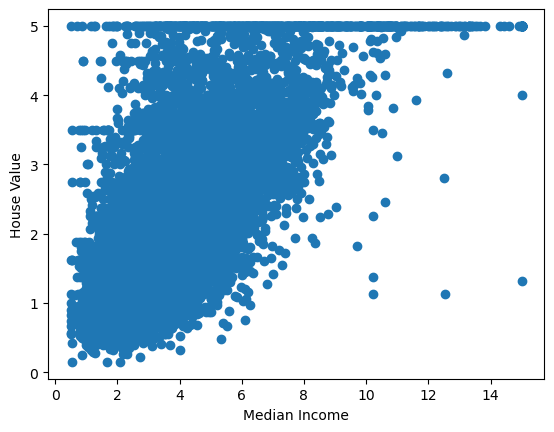

In [5]:
plt.scatter(X_train['MedInc'], y_train)
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.show()

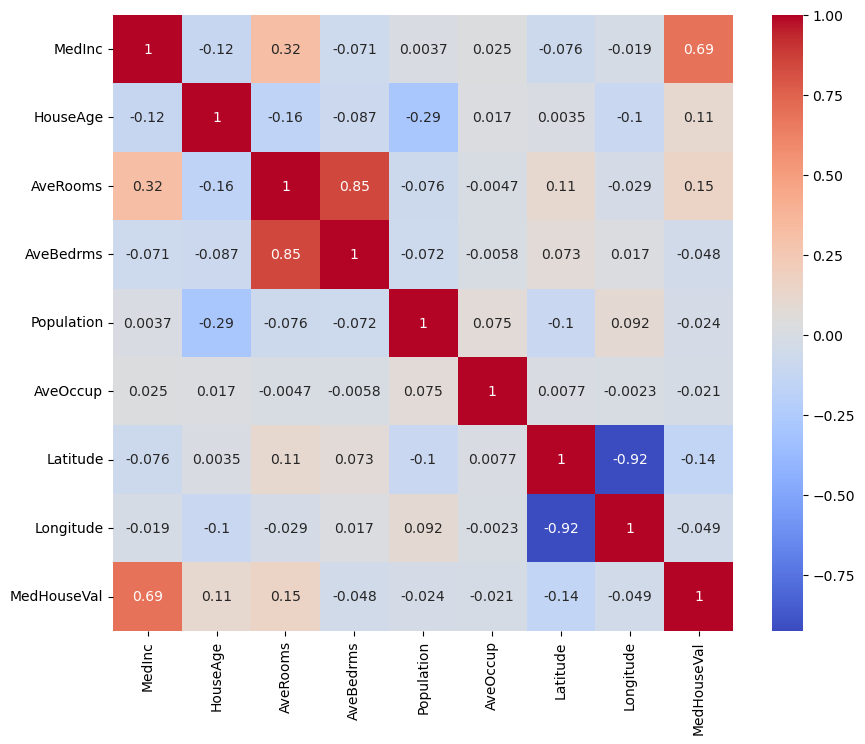

In [6]:
plt.figure(figsize=(10,8))
sns.heatmap(pd.concat([X_train, y_train], axis=1).corr(),
            annot=True, cmap='coolwarm')
plt.show()

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Using only MedInc
model_simple = LinearRegression()
model_simple.fit(X_train[['MedInc']], y_train)

y_pred_simple = model_simple.predict(X_test[['MedInc']])

print("MSE:", mean_squared_error(y_test, y_pred_simple))
print("R2:", r2_score(y_test, y_pred_simple))

MSE: 0.6608572198292422
R2: 0.5002253561465753


In [8]:
model_multi = LinearRegression()
model_multi.fit(X_train_scaled, y_train)

y_pred_multi = model_multi.predict(X_test_scaled)

print("MSE:", mean_squared_error(y_test, y_pred_multi))
print("R2:", r2_score(y_test, y_pred_multi))

MSE: 0.5202604958440162
R2: 0.6065519204153755


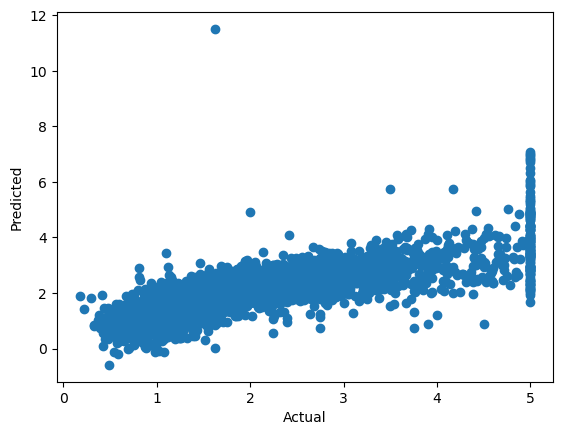

In [9]:
plt.scatter(y_test, y_pred_multi)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [10]:
y_train_class = pd.qcut(y_train, 3, labels=[0,1,2])
y_val_class = pd.qcut(y_val, 3, labels=[0,1,2])
y_test_class = pd.qcut(y_test, 3, labels=[0,1,2])

In [11]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train_class)

log_pred = log_model.predict(X_test_scaled)

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train_class)

rf_pred = rf.predict(X_test)

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test_class, rf_pred))
print(confusion_matrix(y_test_class, rf_pred))
print(classification_report(y_test_class, rf_pred))

Accuracy: 0.8200904392764858
[[892 130  12]
 [134 766 130]
 [ 16 135 881]]
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1034
           1       0.74      0.74      0.74      1030
           2       0.86      0.85      0.86      1032

    accuracy                           0.82      3096
   macro avg       0.82      0.82      0.82      3096
weighted avg       0.82      0.82      0.82      3096



In [14]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf')
svm_model.fit(X_train_scaled, y_train_class)

svm_pred = svm_model.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test_class, svm_pred))

SVM Accuracy: 0.7558139534883721


In [15]:
from sklearn.neural_network import MLPClassifier

nn = MLPClassifier(hidden_layer_sizes=(100,50),
                   max_iter=300,
                   random_state=42)

nn.fit(X_train_scaled, y_train_class)

nn_pred = nn.predict(X_test_scaled)

print("NN Accuracy:", accuracy_score(y_test_class, nn_pred))

NN Accuracy: 0.7945736434108527


In [16]:
from flask import Flask, request, render_template
import pickle
import numpy as np

app = Flask(__name__)

model = pickle.load(open('model.pkl','rb'))

@app.route('/')
def home():
    return render_template('index.html')

@app.route('/predict', methods=['POST'])
def predict():
    features = [float(x) for x in request.form.values()]
    final = np.array([features])
    prediction = model.predict(final)
    return render_template('index.html', prediction_text=str(prediction))

if __name__ == "__main__":
    app.run(debug=True)

FileNotFoundError: [Errno 2] No such file or directory: 'model.pkl'

In [18]:
import pickle
pickle.dump(rf, open("model.pkl", "wb"))

In [19]:
import os
os.getcwd()

'C:\\Users\\KIIT0001\\Adlab website'

In [20]:
pickle.dump(scaler, open("scaler.pkl", "wb"))
